In [12]:
!pip install ultralytics opencv-python pandas matplotlib -q

import cv2
import pandas as pd
import os
import shutil
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from IPython.display import Audio, display
import time
import warnings
warnings.filterwarnings('ignore')

# Gun Classes (Target IDs jo gun hain)
# 0=Automatic Rifle, 1=Bazooka, 3=Handgun, 5=Shotgun, 6=SMG, 7=Sniper
GUN_CLASSES = [0, 1, 3, 5, 6, 7]

# Alarm ka function
def play_alarm():
    display(Audio(url="https://www.soundjay.com/misc/sounds/bell-ringing-05.mp3", autoplay=True))
    print("\033[91m" + "🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨" + "\033[0m")

print("✅ Sab libraries load ho gayin!")

✅ Sab libraries load ho gayin!


In [16]:
from google.colab import files
import zipfile, os, shutil

print("📤 Apni ZIP file upload karein...")
uploaded = files.upload()

# Find the uploaded zip file
zip_filename = None
for fname in uploaded.keys():
    if fname.endswith('.zip'):
        zip_filename = fname
        break

if zip_filename is None:
    print("❌ Koi ZIP file upload nahi hui.")
else:
    print(f"✅ ZIP upload ho gayi: {zip_filename}")

    # Extract
    extract_path = '/content/weapon_dataset'
    if os.path.exists(extract_path):
        shutil.rmtree(extract_path)

    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"✅ Extract ho gayi: {extract_path}")

    # Delete zip to free space
    os.remove(zip_filename)
    print("✅ ZIP delete kar di gayi (jagah bachane ke liye).")

    # Set DATA_PATH
    DATA_PATH = extract_path
    # ... rest of setup (metadata load, symlinks)

📤 Apni ZIP file upload karein...


Saving weapon_detection.zip to weapon_detection (1).zip
✅ ZIP upload ho gayi: weapon_detection (1).zip
✅ Extract ho gayi: /content/weapon_dataset
✅ ZIP delete kar di gayi (jagah bachane ke liye).


In [26]:
import os
import pandas as pd
import shutil

# For robustness, we will always recreate the dataset structure by copying files
# to avoid potential issues with symlinks or previous incomplete setup.

print("⚠️ Recreating YOLO dataset structure by copying files...")

# Define paths
extract_path = '/content/weapon_dataset'
yolo_dataset_path = 'yolo_dataset'
csv_path = os.path.join(extract_path, 'metadata.csv')

# Debugging: Check contents of extracted dataset
print(f"Contents of {extract_path}: {os.listdir(extract_path) if os.path.exists(extract_path) else 'Does not exist'}")
if os.path.exists(os.path.join(extract_path, 'train', 'images')):
    print(f"Contents of {os.path.join(extract_path, 'train', 'images')} (first 5): {os.listdir(os.path.join(extract_path, 'train', 'images'))[:5]}")
else:
    print(f"{os.path.join(extract_path, 'train', 'images')} does not exist.")

# Remove existing yolo_dataset if it exists
if os.path.exists(yolo_dataset_path):
    shutil.rmtree(yolo_dataset_path)

# Create necessary directories
os.makedirs(os.path.join(yolo_dataset_path, 'images', 'train'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'images', 'val'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'labels', 'train'), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, 'labels', 'val'), exist_ok=True)

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    train_df = df[df['train_id'] == 1]
    val_df = df[df['train_id'] == 0]

    # Copy files for training set
    print(f"Copying {len(train_df)} training files...")
    for idx, row in train_df.iterrows():
        src_image_path = os.path.join(extract_path, 'train', 'images', row['imagefile'])
        dst_image_path = os.path.join(yolo_dataset_path, 'images', 'train', row['imagefile'])
        src_label_path = os.path.join(extract_path, 'train', 'labels', row['labelfile'])
        dst_label_path = os.path.join(yolo_dataset_path, 'labels', 'train', row['labelfile'])

        if os.path.exists(src_image_path):
            shutil.copy(src_image_path, dst_image_path)
            if os.path.exists(src_label_path):
                shutil.copy(src_label_path, dst_label_path)
            # else:
            #     print(f"Warning: Label file not found for {src_image_path} at {src_label_path}")
        else:
            print(f"Warning: Image file not found at {src_image_path} during training file copy.")


    # Copy files for validation set
    print(f"Copying {len(val_df)} validation files...")
    for idx, row in val_df.iterrows():
        src_image_path = os.path.join(extract_path, 'val', 'images', row['imagefile'])
        dst_image_path = os.path.join(yolo_dataset_path, 'images', 'val', row['imagefile'])
        src_label_path = os.path.join(extract_path, 'val', 'labels', row['labelfile'])
        dst_label_path = os.path.join(yolo_dataset_path, 'labels', 'val', row['labelfile'])

        if os.path.exists(src_image_path):
            shutil.copy(src_image_path, dst_image_path)
            if os.path.exists(src_label_path):
                shutil.copy(src_label_path, dst_label_path)
            # else:
            #     print(f"Warning: Label file not found for {src_image_path} at {src_label_path}")
        else:
            print(f"Warning: Image file not found at {src_image_path} during validation file copy.")

    # Define and write data.yaml
    data_yaml = f"""
path: /content/{yolo_dataset_path}
train: images/train
val: images/val
nc: 9
names: ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
"""
    with open('data.yaml', 'w') as f:
        f.write(data_yaml)
    print("✅ Setup complete! Files copied and data.yaml created.")

    # Add debugging: List contents of newly created directories
    print(f"Contents of {os.path.join(yolo_dataset_path, 'images', 'train')}:")
    print(os.listdir(os.path.join(yolo_dataset_path, 'images', 'train'))[:5]) # Show first 5 files
    print(f"Number of training images: {len(os.listdir(os.path.join(yolo_dataset_path, 'images', 'train')))}")

    print(f"Contents of {os.path.join(yolo_dataset_path, 'images', 'val')}:")
    print(os.listdir(os.path.join(yolo_dataset_path, 'images', 'val'))[:5]) # Show first 5 files
    print(f"Number of validation images: {len(os.listdir(os.path.join(yolo_dataset_path, 'images', 'val')))}")

    print(f"Contents of {os.path.join(yolo_dataset_path, 'labels', 'train')}:")
    print(os.listdir(os.path.join(yolo_dataset_path, 'labels', 'train'))[:5]) # Show first 5 files
    print(f"Number of training labels: {len(os.listdir(os.path.join(yolo_dataset_path, 'labels', 'train')))}")

    print(f"Contents of {os.path.join(yolo_dataset_path, 'labels', 'val')}:")
    print(os.listdir(os.path.join(yolo_dataset_path, 'labels', 'val'))[:5]) # Show first 5 files
    print(f"Number of validation labels: {len(os.listdir(os.path.join(yolo_dataset_path, 'labels', 'val')))}")

else:
    print("❌ metadata.csv nahi mili. ZIP ka structure check karein.")

⚠️ Recreating YOLO dataset structure by copying files...
Contents of /content/weapon_dataset: ['train', 'test', 'metadata.csv', 'val']
Contents of /content/weapon_dataset/train/images (first 5): ['Handgun_6.jpeg', 'Sword_3.jpeg', 'Sniper_46.jpeg', 'Shotgun_55.jpeg', 'SMG_44.jpeg']
Copying 571 training files...
Copying 143 validation files...
✅ Setup complete! Files copied and data.yaml created.
Contents of yolo_dataset/images/train:
['Handgun_6.jpeg', 'Sword_3.jpeg', 'Sniper_46.jpeg', 'Shotgun_55.jpeg', 'SMG_44.jpeg']
Number of training images: 571
Contents of yolo_dataset/images/val:
['Sniper_98.jpeg', 'Knife_60.jpeg', 'Sword_77.jpeg', 'Sword_89.jpeg', 'Sword_86.jpeg']
Number of validation images: 143
Contents of yolo_dataset/labels/train:
['Knife_23.txt', 'Bazooka_99.txt', 'Automatic Rifle_56.txt', 'Handgun_88.txt', 'Automatic Rifle_48.txt']
Number of training labels: 571
Contents of yolo_dataset/labels/val:
['Grenade Launcher_47.txt', 'Automatic Rifle_50.txt', 'Bazooka_18.txt', 'Swo

In [27]:
import warnings
warnings.filterwarnings('ignore')
# Libraries Install
!pip install ultralytics opencv-python-headless -q

from ultralytics import YOLO

print("🚀 Training start ho rahi hai... (20-30 minute lage sakte hain)")

# Model load karein
model = YOLO('yolov8n.pt')

# Train start
model.train(
    data='data.yaml',
    epochs=10,        # 30 epochs theek hain
    imgsz=640,
    batch=8,          # Agar memory error aaye toh 4 kar dein
    device='cpu'          # GPU use karega
)

print("✅ Training complete! Model saved at: /content/runs/detect/train/weights/best.pt")

🚀 Training start ho rahi hai... (20-30 minute lage sakte hain)
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, opti

In [29]:
from ultralytics import YOLO
import os

# 🔴 SAHI PATH (train-5 wala)
model_path = '/content/runs/detect/train-5/weights/best.pt'

if os.path.exists(model_path):
    model = YOLO(model_path)
    print("✅ Load the model:", model_path)
else:
    print("❌ Not have a model")

✅ Load the model: /content/runs/detect/train-5/weights/best.pt



image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_13.jpeg: 352x640 1 Automatic Rifle, 440.4ms
Speed: 5.6ms preprocess, 440.4ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)


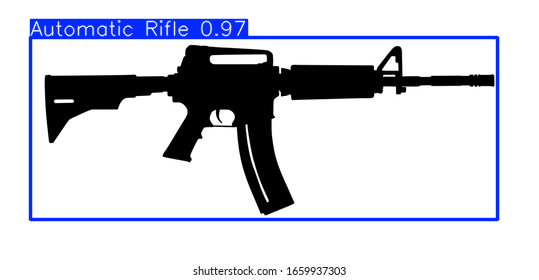

🔍 Detected: Automatic Rifle (Confidence: 0.97)


In [31]:
from google.colab.patches import cv2_imshow
import cv2
import os
import glob

# Model load (agar pehle se load nahi hai)
if 'model' not in dir():
    from ultralytics import YOLO
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')

class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']

# Test image (apni marzi ki image de sakti hain)
test_img = '/content/yolo_dataset/images/val/Automatic Rifle_13.jpeg'  # <-- Isko change karein

if not os.path.exists(test_img):
    # Koi aur image dhoondein
    images = glob.glob('/content/yolo_dataset/images/val/*.jpeg')
    if images:
        test_img = images[0]
    else:
        print("❌ Koi image nahi mili.")
        test_img = None

if test_img and os.path.exists(test_img):
    results = model(test_img)
    annotated = results[0].plot()
    cv2_imshow(annotated)

    # Detected objects print karein
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            name = class_names[cls_id]
            print(f"🔍 Detected: {name} (Confidence: {conf:.2f})")
else:
    print("❌ Image nahi mili.")


image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_13.jpeg: 352x640 1 Automatic Rifle, 153.0ms
Speed: 4.4ms preprocess, 153.0ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 640)


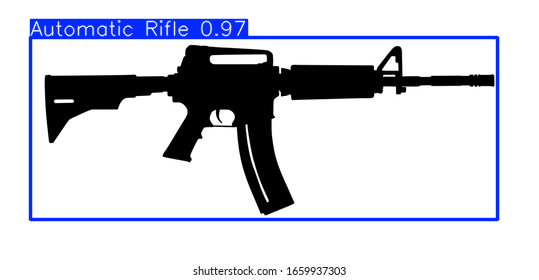

🔍 Detected: Automatic Rifle (Confidence: 0.97)


<IPython.core.display.Javascript object>

🚨🚨 ALARM! GUN DETECTED! 🚨🚨


In [43]:
from google.colab.patches import cv2_imshow
import cv2
import os
import glob
from IPython.display import display, Javascript, Audio
import json

# Model load
if 'model' not in dir():
    from ultralytics import YOLO
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')

class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
GUN_CLASSES = [0, 1, 3, 5, 6, 7]
KNIFE_ID = 4

# JavaScript function to play beep
def play_beep():
    js_code = """
    var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    var oscillator = audioCtx.createOscillator();
    var gainNode = audioCtx.createGain();
    oscillator.connect(gainNode);
    gainNode.connect(audioCtx.destination);
    oscillator.frequency.value = 800;
    oscillator.type = 'square';
    gainNode.gain.value = 0.3;
    oscillator.start();
    setTimeout(function() { oscillator.stop(); }, 300);
    """
    display(Javascript(js_code))

# Alarm function with both JS beep and Audio fallback
def play_alarm():
    play_beep()  # JavaScript beep
    # Fallback audio (user might need to click play)
    display(Audio(url="https://www.soundjay.com/misc/sounds/bell-ringing-05.mp3", autoplay=True))
    print("\033[91m" + "🚨🚨 ALARM! GUN DETECTED! 🚨🚨" + "\033[0m")

# Test image
test_img = '/content/yolo_dataset/images/val/Automatic Rifle_13.jpeg'  # <-- Change karein

if not os.path.exists(test_img):
    images = glob.glob('/content/yolo_dataset/images/val/*.jpeg')
    if images:
        test_img = images[0]

if test_img and os.path.exists(test_img):
    results = model(test_img)
    annotated = results[0].plot()
    cv2_imshow(annotated)

    gun_detected = False
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            name = class_names[cls_id]
            print(f"🔍 Detected: {name} (Confidence: {conf:.2f})")

            if cls_id in GUN_CLASSES:
                gun_detected = True
                play_alarm()
            elif cls_id == KNIFE_ID:
                print("🔪 KNIFE DETECTED!")

    if not gun_detected:
        print("✅ No gun detected.")
else:
    print("❌ Image nahi mili.")


image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_13.jpeg: 352x640 1 Automatic Rifle, 283.1ms
Speed: 4.0ms preprocess, 283.1ms inference, 7.3ms postprocess per image at shape (1, 3, 352, 640)


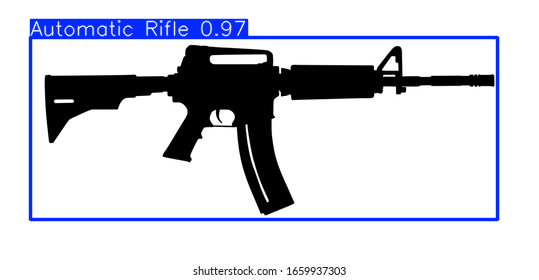

🔍 Detected: Automatic Rifle (Confidence: 0.97)


🚨🚨 ALARM! GUN DETECTED! 🚨🚨


In [30]:
from google.colab.patches import cv2_imshow
import cv2
from IPython.display import Audio, display

# Classes
class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
GUN_CLASSES = [0, 1, 3, 5, 6, 7]  # Gun IDs
KNIFE_ID = 4

# Alarm function
def play_alarm():
    display(Audio(url="https://www.soundjay.com/misc/sounds/bell-ringing-05.mp3", autoplay=True))
    print("\033[91m" + "🚨🚨 ALARM! GUN DETECTED! 🚨🚨" + "\033[0m")

# Test image (validation set ki pehli image)
test_img = '/content/yolo_dataset/images/val/Automatic Rifle_13.jpeg'  # <-- Isko apni marzi ki image se change kar sakti hain

if not os.path.exists(test_img):
    # Agar yeh image na ho toh koi aur image dhoondein
    import glob
    images = glob.glob('/content/yolo_dataset/images/val/*.jpeg')
    if images:
        test_img = images[0]
    else:
        print("❌ Koi test image nahi mili.")
        test_img = None

if test_img and os.path.exists(test_img):
    results = model(test_img)
    annotated = results[0].plot()
    cv2_imshow(annotated)

    # Check karein ke kya detect hua
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            name = class_names[cls_id]
            print(f"🔍 Detected: {name} (Confidence: {conf:.2f})")

            if cls_id in GUN_CLASSES:
                play_alarm()
            elif cls_id == KNIFE_ID:
                print("🔪 KNIFE DETECTED!")
else:
    print("❌ Image nahi mili. Koi aur path de kar try karein.")

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import os
import glob
from IPython.display import display, Javascript, Audio

# ---- Model Load (agar pehle se nahi hai) ----
if 'model' not in dir():
    from ultralytics import YOLO
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')
    print("✅ Model loaded!")

# ---- Classes ----
class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
GUN_CLASSES = [0, 1, 3, 5, 6, 7]
KNIFE_ID = 4

# ---- Alarm Function (JS Beep) ----
def play_beep():
    js_code = """
    var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    var oscillator = audioCtx.createOscillator();
    var gainNode = audioCtx.createGain();
    oscillator.connect(gainNode);
    gainNode.connect(audioCtx.destination);
    oscillator.frequency.value = 800;
    oscillator.type = 'square';
    gainNode.gain.value = 0.3;
    oscillator.start();
    setTimeout(function() { oscillator.stop(); }, 300);
    """
    display(Javascript(js_code))

def play_alarm():
    play_beep()
    print("\033[91m" + "🚨🚨 ALARM! GUN DETECTED! 🚨🚨" + "\033[0m")

# ------------------------------------------------
# 🔴 OPTION 1: APNE MAN PASAND IMAGES KA LIST (Specific test)
# ------------------------------------------------
# Comment out (hash) agar specific images test karni hain.
# test_images = [
#     '/content/yolo_dataset/images/val/Automatic Rifle_13.jpeg',
#     '/content/yolo_dataset/images/val/Shotgun_55.jpeg',
#     '/content/yolo_dataset/images/val/Knife_60.jpeg',
#     '/content/yolo_dataset/images/val/Handgun_6.jpeg'
# ]

# ------------------------------------------------
# OPTION 2: Validation folder se automatically pehli 5 images lein
# ------------------------------------------------
if 'test_images' not in dir():
    # Validation folder mein images dhoondein
    val_folder = '/content/yolo_dataset/images/val/'
    # Sab .jpeg, .jpg, .png files collect karein
    all_images = []
    for ext in ['*.jpeg', '*.jpg', '*.png']:
        all_images.extend(glob.glob(os.path.join(val_folder, ext)))

    # Pehli 5 images lein (agar 5 se kam hain toh jitni hain)
    test_images = sorted(all_images)[:5]

if not test_images:
    print("❌ Koi test image nahi mili! Folder check karein.")
else:
    print(f"📸 Total {len(test_images)} images test ki ja rahi hain...\n")
    print("="*60)

    # Har image par loop
    for idx, img_path in enumerate(test_images):
        print(f"\n🖼️  Image #{idx+1}: {os.path.basename(img_path)}")
        print("-" * 40)

        # Detection
        results = model(img_path)
        annotated = results[0].plot()
        cv2_imshow(annotated)

        # Results print karein
        detected_objects = []
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                name = class_names[cls_id]
                detected_objects.append((name, conf, cls_id))
                print(f"   🔍 Detected: {name} (Confidence: {conf:.2f})")

                # Alarm sirf gun par bajayein
                if cls_id in GUN_CLASSES:
                    play_alarm()
                elif cls_id == KNIFE_ID:
                    print("   🔪 KNIFE detected!")

        if not detected_objects:
            print("   ✅ No weapon detected.")

        print("="*60)

    print("\n🎯 complete images testing!")

📸 Total 5 images test ki ja rahi hain...


🖼️  Image #1: Automatic Rifle_13.jpeg
----------------------------------------

image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_13.jpeg: 352x640 1 Automatic Rifle, 184.5ms
Speed: 4.2ms preprocess, 184.5ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)


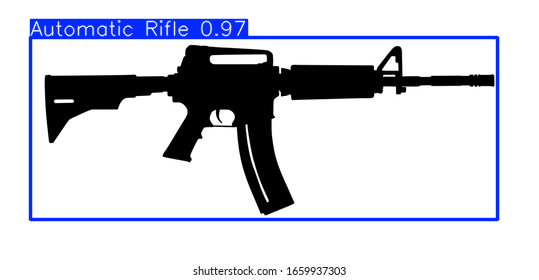

   🔍 Detected: Automatic Rifle (Confidence: 0.97)


<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM! 🚨🚨

🖼️  Image #2: Automatic Rifle_19.jpeg
----------------------------------------

image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_19.jpeg: 384x640 1 Automatic Rifle, 171.0ms
Speed: 5.1ms preprocess, 171.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


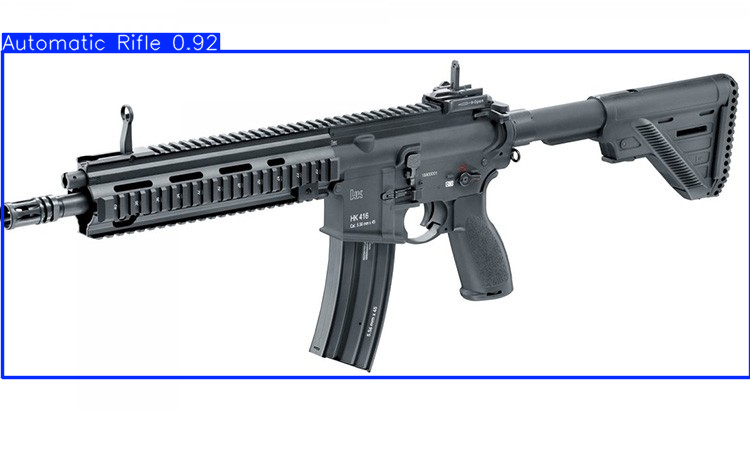

   🔍 Detected: Automatic Rifle (Confidence: 0.92)


<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM! 🚨🚨

🖼️  Image #3: Automatic Rifle_28.png
----------------------------------------

image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_28.png: 480x640 1 Shotgun, 210.0ms
Speed: 5.0ms preprocess, 210.0ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


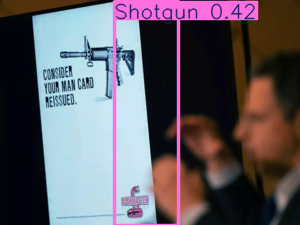

   🔍 Detected: Shotgun (Confidence: 0.42)


<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM! 🚨🚨

🖼️  Image #4: Automatic Rifle_35.jpeg
----------------------------------------

image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_35.jpeg: 384x640 1 Automatic Rifle, 1 Grenade Launcher, 164.0ms
Speed: 5.0ms preprocess, 164.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


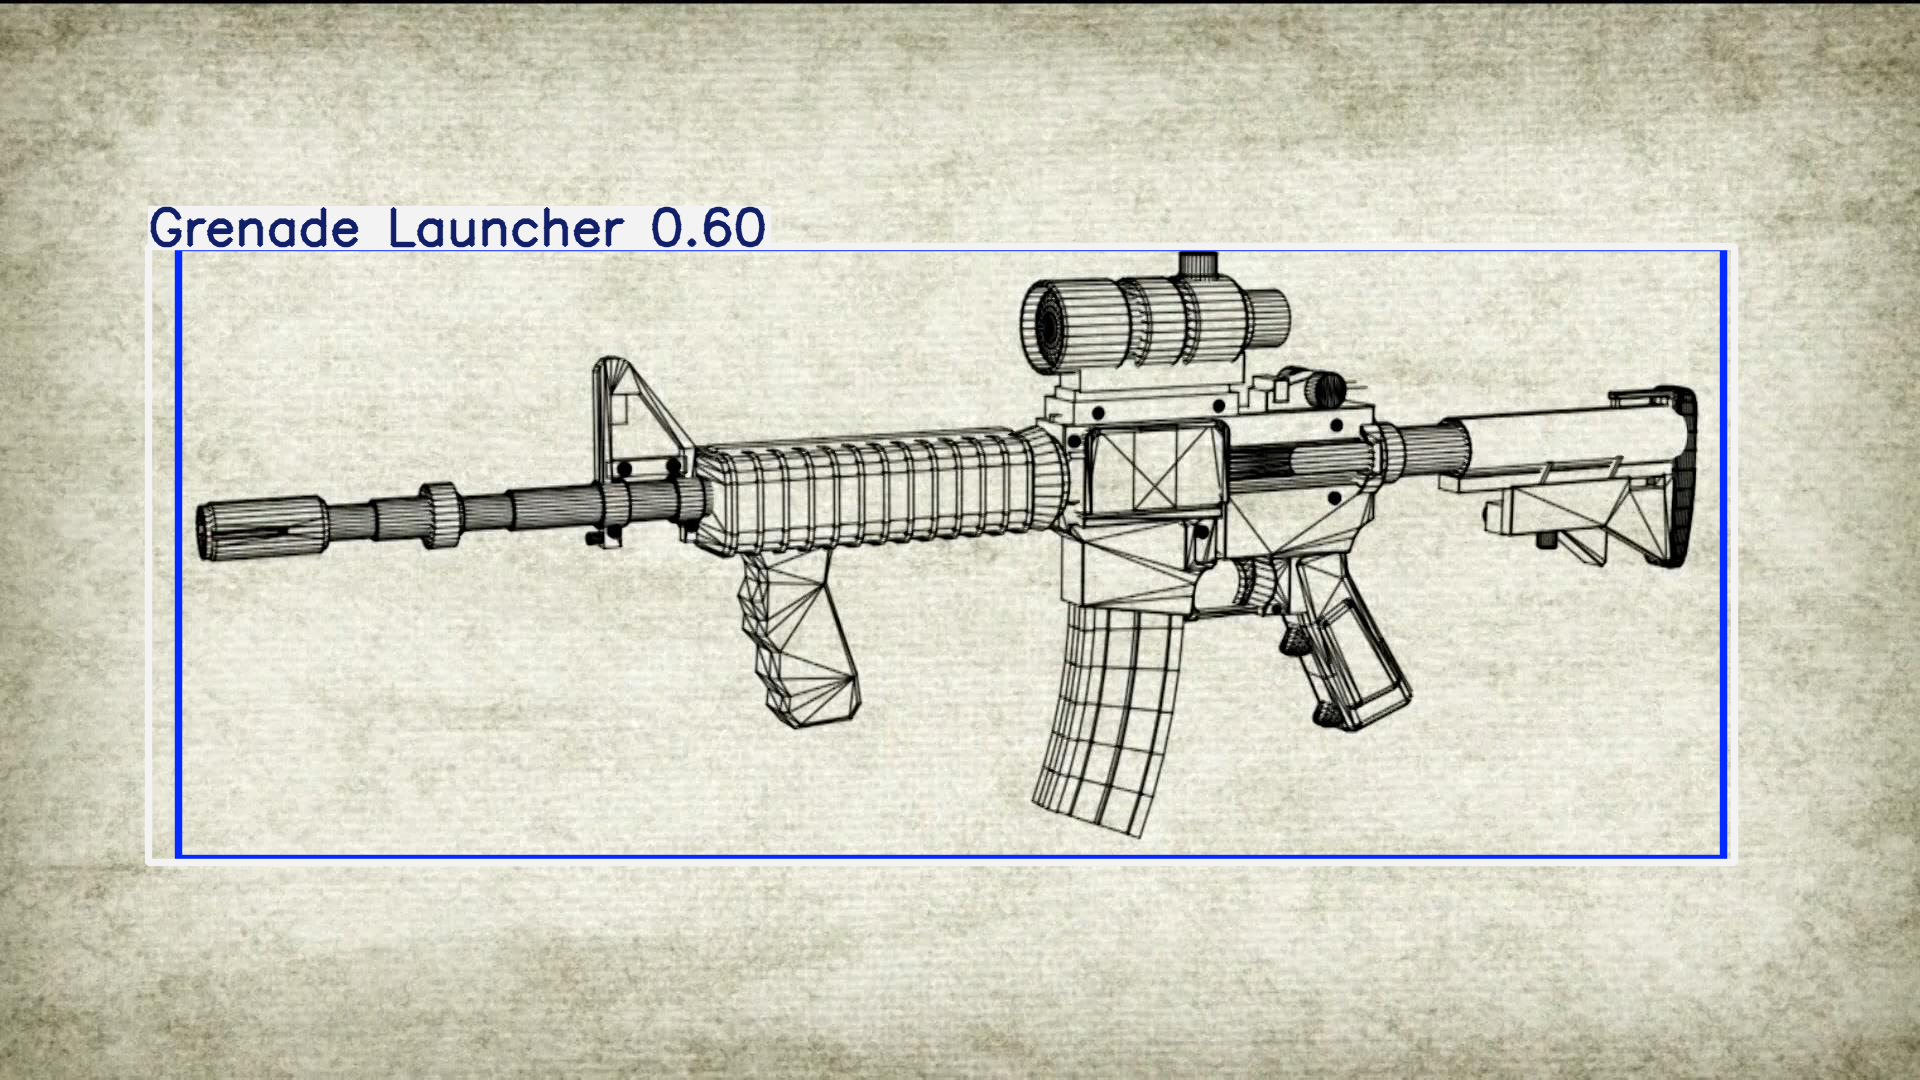

   🔍 Detected: Grenade Launcher (Confidence: 0.60)
   🔍 Detected: Automatic Rifle (Confidence: 0.33)


<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM! 🚨🚨

🖼️  Image #5: Automatic Rifle_40.jpeg
----------------------------------------

image 1/1 /content/yolo_dataset/images/val/Automatic Rifle_40.jpeg: 480x640 1 Automatic Rifle, 283.9ms
Speed: 6.0ms preprocess, 283.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


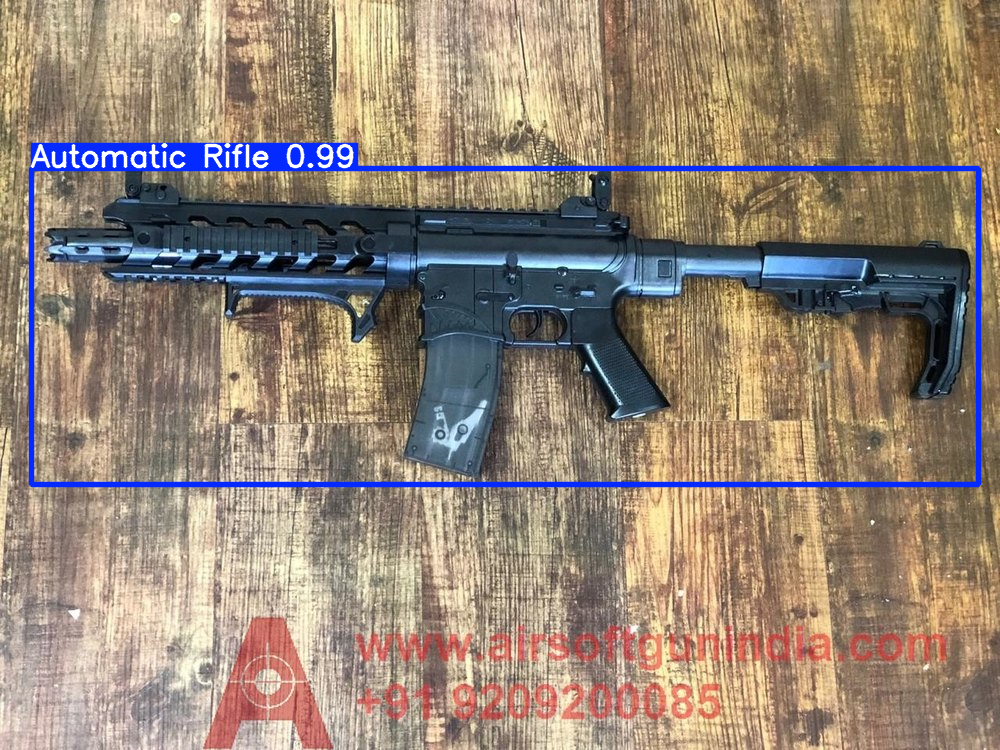

   🔍 Detected: Automatic Rifle (Confidence: 0.99)


<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM! 🚨🚨

🎯 Sab images ka test complete ho gaya! Alarm cleanly band ho jayega.


In [48]:
from google.colab.patches import cv2_imshow
import cv2
import os
import glob
from IPython.display import display, Javascript, Audio

# ---- Model Load (agar pehle se nahi hai) ----
if 'model' not in dir():
    from ultralytics import YOLO
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')
    print("✅ Model loaded!")

# ---- Classes ----
class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
GUN_CLASSES = [0, 1, 3, 5, 6, 7]
KNIFE_ID = 4

# ---- 🔥 IMPROVED ALARM (Hamesha band ho jayega) ----
def play_beep():
    js_code = """
    // Agar pehle se koi beep chal rahi hai toh band karein
    if (window._osc) {
        try { window._osc.stop(); } catch(e) {}
        window._osc = null;
    }

    var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    var oscillator = audioCtx.createOscillator();
    var gainNode = audioCtx.createGain();

    oscillator.connect(gainNode);
    gainNode.connect(audioCtx.destination);

    oscillator.frequency.value = 800;  // 800 Hz
    oscillator.type = 'square';
    gainNode.gain.value = 0.3;  // Volume

    oscillator.start();

    // Oscillator ko store karein taake baad mein band kar saken
    window._osc = oscillator;

    // 300ms (0.3 second) baad band karein
    setTimeout(function() {
        if (window._osc) {
            try { window._osc.stop(); } catch(e) {}
            window._osc = null;
        }
    }, 300);
    """
    display(Javascript(js_code))

def play_alarm():
    play_beep()
    print("\033[91m" + "🚨🚨 GUN DETECTED! ALARM! 🚨🚨" + "\033[0m")

# ------------------------------------------------
# OPTION 1: Specific images test
# ------------------------------------------------
# test_images = [
#     '/content/yolo_dataset/images/val/Automatic Rifle_13.jpeg',
#     '/content/yolo_dataset/images/val/Shotgun_55.jpeg',
#     '/content/yolo_dataset/images/val/Knife_60.jpeg',
# ]

# ------------------------------------------------
# OPTION 2: Auto pehli 5 images
# ------------------------------------------------
if 'test_images' not in dir():
    val_folder = '/content/yolo_dataset/images/val/'
    all_images = []
    for ext in ['*.jpeg', '*.jpg', '*.png']:
        all_images.extend(glob.glob(os.path.join(val_folder, ext)))
    test_images = sorted(all_images)[:5]  # Pehli 5 images

if not test_images:
    print("❌ Koi test image nahi mili!")
else:
    print(f"📸 Total {len(test_images)} images test ki ja rahi hain...\n")
    print("="*60)

    for idx, img_path in enumerate(test_images):
        print(f"\n🖼️  Image #{idx+1}: {os.path.basename(img_path)}")
        print("-" * 40)

        # Detection
        results = model(img_path)
        annotated = results[0].plot()
        cv2_imshow(annotated)

        # 🔥 IMPORTANT: Har image ke liye alarm "reset"
        alarm_baja = False  # Is image mein abhi tak alarm nahi baja

        detected_objects = []
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                name = class_names[cls_id]
                detected_objects.append((name, conf, cls_id))
                print(f"   🔍 Detected: {name} (Confidence: {conf:.2f})")

                # 🚨 Sirf GUN par aur SIRF EK BAAR alarm bajayein
                if cls_id in GUN_CLASSES and not alarm_baja:
                    alarm_baja = True
                    play_alarm()  # Bas ek baar
                elif cls_id == KNIFE_ID:
                    print("   🔪 KNIFE detected!")

        if not detected_objects:
            print("   ✅ No weapon detected.")

        print("="*60)

    print("\n🎯 Sab images ka test complete ho gaya! Alarm cleanly band ho jayega.")

In [55]:
from google.colab import files
files.download('output_video.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
from IPython.display import HTML
from base64 import b64encode

def play_video(file_path):
    video_file = open(file_path, 'rb').read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""
    <video width="700" controls>
        <source src="{video_url}" type="video/mp4">
    </video>
    """)

display(play_video('output_video.mp4'))

In [57]:
# ==========================================
# VIDEO DETECTION: AUTO SEARCH + UPLOAD
# ==========================================

from ultralytics import YOLO
import cv2
import os
import glob
from IPython.display import display, Audio, Video, Javascript
import time
from google.colab import files

# ---- Load the trained model ----
if 'model' not in dir():
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')
    print("✅ Model loaded successfully!")

# ---- Define class names and gun IDs ----
class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
GUN_CLASSES = [0, 1, 3, 5, 6, 7]  # Gun class IDs

# ---- Alarm Function (Stops previous sound before playing new one) ----
def play_beep():
    js_code = """
    if (window._osc) {
        try { window._osc.stop(); } catch(e) {}
        window._osc = null;
    }
    var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    var oscillator = audioCtx.createOscillator();
    var gainNode = audioCtx.createGain();
    oscillator.connect(gainNode);
    gainNode.connect(audioCtx.destination);
    oscillator.frequency.value = 800;  # 800 Hz frequency
    oscillator.type = 'square';
    gainNode.gain.value = 0.3;  # Volume level
    oscillator.start();
    window._osc = oscillator;
    setTimeout(function() {
        if (window._osc) {
            try { window._osc.stop(); } catch(e) {}
            window._osc = null;
        }
    }, 300);  # Stop after 300ms
    """
    display(Javascript(js_code))

def play_alarm():
    play_beep()
    print("\033[91m" + "🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨" + "\033[0m")

# ================================================
# 🔍 STEP 1: Search for videos (Case-Insensitive)
# ================================================

# Root folders where your dataset might be stored
possible_roots = [
    '/content/weapon_dataset',
    '/content/weapon_detection',
]

search_roots = [root for root in possible_roots if os.path.exists(root)]

if not search_roots:
    print("❌ No dataset folder found. Please check if 'weapon_dataset' or 'weapon_detection' exists.")
    video_files = []
else:
    print(f"🔍 Searching for videos in: {search_roots}")
    video_files = []

    # List of video extensions (case-insensitive)
    video_exts = {'.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv', '.m4v', '.webm',
                  '.MP4', '.AVI', '.MOV', '.MKV', '.FLV', '.WMV', '.M4V', '.WEBM'}

    for root in search_roots:
        # ===== 🔥 DEBUG: Print folder contents to see what's inside =====
        print(f"\n📂 Checking contents of: {root}")
        try:
            print(f"   Direct items: {os.listdir(root)}")
            # Check inside train, test, val if they exist
            for sub in ['train', 'test', 'val']:
                sub_path = os.path.join(root, sub)
                if os.path.exists(sub_path):
                    print(f"   Contents of '{sub}': {os.listdir(sub_path)[:10]} (showing first 10)")
        except:
            pass

        # Deep search for videos
        for dirpath, dirnames, filenames in os.walk(root):
            for file in filenames:
                ext = os.path.splitext(file)[1]  # Get file extension
                if ext in video_exts:
                    full_path = os.path.join(dirpath, file)
                    video_files.append(full_path)

# ================================================
# 📋 STEP 2: If videos are found, let user select one
# ================================================

if video_files:
    print(f"\n✅ Total {len(video_files)} video(s) found:\n")
    for idx, path in enumerate(video_files):
        file_name = os.path.basename(path)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"   [{idx+1}] {file_name} ({size_mb:.1f} MB)")

    print("\n" + "-" * 40)
    choice = input(f"👉 Enter the number of the video to process (1-{len(video_files)}), or press Enter to select the first video: ")

    if choice.strip() == "":
        selected_idx = 0
    else:
        try:
            selected_idx = int(choice) - 1
        except:
            print("❌ Invalid number. Selecting the first video.")
            selected_idx = 0

    if selected_idx < 0 or selected_idx >= len(video_files):
        print("❌ Number out of range. Selecting the first video.")
        selected_idx = 0

    video_path = video_files[selected_idx]
    print(f"\n✅ Selected Video: {os.path.basename(video_path)}")

# ================================================
# 📤 STEP 3: If no videos are found, upload a video
# ================================================

else:
    print("❌ No video found in the folders.")
    print("👉 You can upload a video file now (MP4 recommended)...")
    uploaded = files.upload()
    video_path = None
    for fname in uploaded.keys():
        video_path = fname
        break

    if not video_path:
        print("❌ No video uploaded. Stopping process.")
        video_path = None

# ================================================
# 🎬 STEP 4: Process the selected/uploaded video
# ================================================

if video_path and os.path.exists(video_path):
    print(f"✅ Video loaded: {video_path}")

    # Open video file
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    if fps <= 0: fps = 30  # Set default if FPS is missing
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"📹 Video Info: {w}x{h}, {fps} FPS")

    # Prepare output video writer
    out = cv2.VideoWriter('output_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    frame_count = 0
    total_guns = 0
    last_alarm_time = 0  # Cooldown timer to avoid continuous alarms

    print("\n⏳ Processing video... (This may take 2-5 minutes depending on video length)")
    print("-" * 50)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Run detection on every 2nd frame to improve speed
        if frame_count % 2 == 0:
            results = model(frame)
            annotated_frame = results[0].plot()

            # Check if a gun is detected in this frame
            gun_detected = False
            for r in results:
                for box in r.boxes:
                    cls_id = int(box.cls[0])
                    if cls_id in GUN_CLASSES:
                        gun_detected = True
                        total_guns += 1
                        break
                if gun_detected:
                    break

            # 🔥 Play alarm only if a gun is detected and 2 seconds have passed since the last alarm
            if gun_detected and (time.time() - last_alarm_time) > 2.0:
                play_alarm()
                print(f"🔫 Frame {frame_count}: Gun detected! (Total detections so far: {total_guns})")
                last_alarm_time = time.time()

            out.write(annotated_frame)
        else:
            out.write(frame)  # Write frame without detection (faster)

        # Show progress every 100 frames
        if frame_count % 100 == 0:
            print(f"📊 Processed: {frame_count} frames...")

    cap.release()
    out.release()

    print("-" * 50)
    print(f"✅ Processing complete!")
    print(f"📊 Total frames processed: {frame_count}")
    print(f"🔫 Total gun detections: {total_guns}")
    print("💾 Output video saved as: output_video.mp4")

    # Display the output video
    print("\n▶️ Playing output video:")
    display(Video('output_video.mp4', width=700))

    # If the video was uploaded manually, delete it to free up Colab disk space
    if video_path.startswith('/content/') and 'drive' not in video_path:
        try:
            os.remove(video_path)
            print("✅ Uploaded video deleted to free up space.")
        except:
            pass
else:
    print("❌ Video processing skipped.")

🔍 Searching for videos in: ['/content/weapon_dataset']

📂 Checking contents of: /content/weapon_dataset
   Direct items: ['train', 'test', 'metadata.csv', 'val']
   Contents of 'train': ['images', 'labels'] (showing first 10)
   Contents of 'test': ['test'] (showing first 10)
   Contents of 'val': ['images', 'labels'] (showing first 10)
❌ No video found in the folders.
👉 You can upload a video file now (MP4 recommended)...


Saving mafia-mafia-game.gif to mafia-mafia-game (2).gif
✅ Video loaded: mafia-mafia-game (2).gif
📹 Video Info: 498x280, 20 FPS

⏳ Processing video... (This may take 2-5 minutes depending on video length)
--------------------------------------------------

0: 384x640 1 Automatic Rifle, 153.7ms
Speed: 5.3ms preprocess, 153.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨
🔫 Frame 2: Gun detected! (Total detections so far: 1)

0: 384x640 (no detections), 145.1ms
Speed: 4.0ms preprocess, 145.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 145.8ms
Speed: 3.4ms preprocess, 145.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 146.5ms
Speed: 3.8ms preprocess, 146.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 147.0ms
Speed: 4.0ms preprocess, 147.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 166.2ms
Speed: 3.7ms preprocess, 166.2ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 146.8ms
Speed: 3.9ms preprocess, 146.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 146.2ms
Speed: 4.6ms preprocess, 146.2ms inference, 1.0ms postproces

<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨
🔫 Frame 28: Gun detected! (Total detections so far: 6)

0: 384x640 1 Automatic Rifle, 146.1ms
Speed: 3.6ms preprocess, 146.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 145.4ms
Speed: 4.4ms preprocess, 145.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 144.7ms
Speed: 4.8ms preprocess, 144.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 143.2ms
Speed: 4.4ms preprocess, 143.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 156.1ms
Speed: 3.7ms preprocess, 156.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 144.3ms
Speed: 3.5ms preprocess, 144.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 148.1ms
Speed: 4.0ms preprocess, 148.1ms inference, 1.1

<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨
🔫 Frame 58: Gun detected! (Total detections so far: 14)

0: 384x640 1 Automatic Rifle, 142.3ms
Speed: 4.0ms preprocess, 142.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 165.0ms
Speed: 3.8ms preprocess, 165.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 147.3ms
Speed: 3.3ms preprocess, 147.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 143.4ms
Speed: 3.7ms preprocess, 143.4ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 143.8ms
Speed: 3.5ms preprocess, 143.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 142.6ms
Speed: 4.4ms preprocess, 142.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 146.4ms
Speed: 2.8ms preprocess, 146.4ms inference, 0.6ms post

In [58]:
# ==========================================
# VIDEO DETECTION: COMPLETE WITH AUTO SEARCH
# ==========================================

from ultralytics import YOLO
import cv2
import os
import glob
from IPython.display import display, Audio, Video, Javascript, HTML
import time
from google.colab import files
from base64 import b64encode

# ---- Load Model ----
if 'model' not in dir():
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')
    print("✅ Model loaded successfully!")

# ---- Classes ----
class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
GUN_CLASSES = [0, 1, 3, 5, 6, 7]

# ---- Alarm Function ----
def play_beep():
    js_code = """
    if (window._osc) {
        try { window._osc.stop(); } catch(e) {}
        window._osc = null;
    }
    var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    var oscillator = audioCtx.createOscillator();
    var gainNode = audioCtx.createGain();
    oscillator.connect(gainNode);
    gainNode.connect(audioCtx.destination);
    oscillator.frequency.value = 800;
    oscillator.type = 'square';
    gainNode.gain.value = 0.3;
    oscillator.start();
    window._osc = oscillator;
    setTimeout(function() {
        if (window._osc) {
            try { window._osc.stop(); } catch(e) {}
            window._osc = null;
        }
    }, 300);
    """
    display(Javascript(js_code))

def play_alarm():
    play_beep()
    print("\033[91m" + "🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨" + "\033[0m")

# ================================================
# 🔍 STEP 1: Search for videos in weapon_dataset
# ================================================

root_folders = ['/content/weapon_dataset', '/content/weapon_detection']
video_files = []

# Video extensions (case insensitive)
video_exts = {'.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv', '.m4v', '.webm',
              '.MP4', '.AVI', '.MOV', '.MKV', '.FLV', '.WMV', '.M4V', '.WEBM',
              '.gif', '.GIF'}  # GIF bhi support karte hain

for root in root_folders:
    if not os.path.exists(root):
        continue

    print(f"🔍 Searching in: {root}")

    # Deep search using os.walk
    for dirpath, dirnames, filenames in os.walk(root):
        for file in filenames:
            ext = os.path.splitext(file)[1]
            if ext in video_exts:
                full_path = os.path.join(dirpath, file)
                video_files.append(full_path)
                print(f"   🎬 Found: {file}")

# ================================================
# 📋 STEP 2: If videos found, let user select
# ================================================

if video_files:
    print(f"\n✅ Total {len(video_files)} video(s) found:\n")
    for idx, path in enumerate(video_files):
        file_name = os.path.basename(path)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"   [{idx+1}] {file_name} ({size_mb:.1f} MB)")

    print("\n" + "-" * 40)
    choice = input(f"👉 Enter number (1-{len(video_files)}), or press Enter for first: ")

    if choice.strip() == "":
        selected_idx = 0
    else:
        try:
            selected_idx = int(choice) - 1
        except:
            print("❌ Invalid. Selecting first.")
            selected_idx = 0

    if selected_idx < 0 or selected_idx >= len(video_files):
        selected_idx = 0

    video_path = video_files[selected_idx]
    print(f"\n✅ Selected: {os.path.basename(video_path)}")

# ================================================
# 📤 STEP 3: If no videos, upload option
# ================================================

else:
    print("\n❌ No videos found in folders.")
    print("👉 Upload a video file now (MP4 recommended)...")
    uploaded = files.upload()
    video_path = None
    for fname in uploaded.keys():
        video_path = fname
        break

    if not video_path:
        print("❌ No video uploaded. Stopping.")
        video_path = None

# ================================================
# 🎬 STEP 4: Process the video
# ================================================

if video_path and os.path.exists(video_path):
    print(f"\n✅ Processing: {video_path}")

    # Open video
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    if fps <= 0: fps = 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"📹 Video Info: {w}x{h}, {fps} FPS")

    # Output video writer
    out = cv2.VideoWriter('output_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

    frame_count = 0
    total_guns = 0
    last_alarm_time = 0

    print("\n⏳ Processing video... (May take 2-5 minutes)")
    print("-" * 50)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Detection on every 2nd frame
        if frame_count % 2 == 0:
            results = model(frame)
            annotated_frame = results[0].plot()

            # Check for guns
            gun_detected = False
            for r in results:
                for box in r.boxes:
                    cls_id = int(box.cls[0])
                    if cls_id in GUN_CLASSES:
                        gun_detected = True
                        total_guns += 1
                        break
                if gun_detected:
                    break

            # Alarm with 2 second cooldown
            if gun_detected and (time.time() - last_alarm_time) > 2.0:
                play_alarm()
                print(f"🔫 Frame {frame_count}: Gun detected! (Total: {total_guns})")
                last_alarm_time = time.time()

            out.write(annotated_frame)
        else:
            out.write(frame)

        # Progress
        if frame_count % 100 == 0:
            print(f"📊 Processed: {frame_count} frames...")

    cap.release()
    out.release()

    print("-" * 50)
    print(f"✅ Processing complete!")
    print(f"📊 Total frames: {frame_count}")
    print(f"🔫 Total gun detections: {total_guns}")
    print("💾 Output video: output_video.mp4")

    # ================================================
    # 🎬 STEP 5: Play output video (HTML5 player)
    # ================================================
    print("\n▶️ Playing output video:")

    with open('output_video.mp4', 'rb') as f:
        video_data = f.read()
        video_base64 = b64encode(video_data).decode()

    html_player = f"""
    <video width="700" controls autoplay>
        <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """
    display(HTML(html_player))

    # ================================================
    # 📥 STEP 6: Download option
    # ================================================
    print("\n📥 Click below to download:")
    files.download('output_video.mp4')

    # Delete uploaded file to free space
    if video_path.startswith('/content/') and 'drive' not in video_path:
        try:
            os.remove(video_path)
            print("✅ Uploaded video deleted (space freed)")
        except:
            pass

else:
    print("❌ Video processing skipped.")

🔍 Searching in: /content/weapon_dataset
   🎬 Found: mafia-mafia-game.gif
   🎬 Found: giphy.gif
   🎬 Found: weaponsgta5.gif

✅ Total 3 video(s) found:

   [1] mafia-mafia-game.gif (8.5 MB)
   [2] giphy.gif (0.6 MB)
   [3] weaponsgta5.gif (0.8 MB)

----------------------------------------
👉 Enter number (1-3), or press Enter for first: 1

✅ Selected: mafia-mafia-game.gif

✅ Processing: /content/weapon_dataset/test/test/mafia-mafia-game.gif
📹 Video Info: 498x280, 20 FPS

⏳ Processing video... (May take 2-5 minutes)
--------------------------------------------------

0: 384x640 (no detections), 165.2ms
Speed: 8.0ms preprocess, 165.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 144.1ms
Speed: 3.7ms preprocess, 144.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 147.9ms
Speed: 4.4ms preprocess, 147.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections

<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨
🔫 Frame 10: Gun detected! (Total: 1)

0: 384x640 (no detections), 146.8ms
Speed: 3.5ms preprocess, 146.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 157.2ms
Speed: 2.8ms preprocess, 157.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 141.9ms
Speed: 3.9ms preprocess, 141.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 150.6ms
Speed: 4.2ms preprocess, 150.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 142.7ms
Speed: 3.7ms preprocess, 142.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 140.0ms
Speed: 3.7ms preprocess, 140.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 141.0ms
Speed: 4.0ms preprocess, 141.0ms inference, 1.0ms postprocess per image

<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨
🔫 Frame 34: Gun detected! (Total: 10)

0: 384x640 1 Automatic Rifle, 145.8ms
Speed: 2.8ms preprocess, 145.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 158.6ms
Speed: 3.8ms preprocess, 158.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 144.4ms
Speed: 3.9ms preprocess, 144.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 147.8ms
Speed: 2.8ms preprocess, 147.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 144.5ms
Speed: 3.9ms preprocess, 144.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 142.0ms
Speed: 3.8ms preprocess, 142.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 145.3ms
Speed: 3.8ms preprocess, 145.3ms inference, 0.6ms postprocess per imag

...

🚨🚨 GUN DETECTED! ALARM TRIGGERED! 🚨🚨
🔫 Frame 58: Gun detected! (Total: 15)

0: 384x640 1 Automatic Rifle, 143.8ms
Speed: 4.0ms preprocess, 143.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 144.4ms
Speed: 4.3ms preprocess, 144.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Automatic Rifle, 161.8ms
Speed: 2.8ms preprocess, 161.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 145.1ms
Speed: 3.7ms preprocess, 145.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 147.3ms
Speed: 3.9ms preprocess, 147.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 141.9ms
Speed: 3.9ms preprocess, 141.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 143.3ms
Speed: 3.9ms preprocess, 143.3ms inference, 0.6ms postprocess per image 


📥 Click below to download:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Uploaded video deleted (space freed)


In [59]:
# ==========================================
# LIVE CAMERA DETECTION (Auto-Capture)
# ==========================================

from ultralytics import YOLO
import cv2
import numpy as np
import base64
import time
from IPython.display import display, Javascript, Image, clear_output
from google.colab.output import eval_js

# ---- Load Model ----
if 'model' not in dir():
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')
    print("✅ Model loaded!")

# ---- Classes ----
class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
GUN_CLASSES = [0, 1, 3, 5, 6, 7]

# ---- Alarm (Beep) ----
def play_beep():
    js_code = """
    if (window._osc) {
        try { window._osc.stop(); } catch(e) {}
        window._osc = null;
    }
    var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    var oscillator = audioCtx.createOscillator();
    var gainNode = audioCtx.createGain();
    oscillator.connect(gainNode);
    gainNode.connect(audioCtx.destination);
    oscillator.frequency.value = 800;
    oscillator.type = 'square';
    gainNode.gain.value = 0.3;
    oscillator.start();
    window._osc = oscillator;
    setTimeout(function() {
        if (window._osc) {
            try { window._osc.stop(); } catch(e) {}
            window._osc = null;
        }
    }, 300);
    """
    display(Javascript(js_code))

def play_alarm():
    play_beep()
    print("\033[91m" + "🚨🚨 GUN DETECTED! ALARM! 🚨🚨" + "\033[0m")

# ---- Function to capture frame from webcam ----
def capture_frame():
    js = Javascript('''
        async function capture() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.width = '400px';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Wait for 200ms to get a stable frame
            await new Promise(resolve => setTimeout(resolve, 200));

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    data = eval_js('capture()')
    binary = base64.b64decode(data.split(',')[1])
    np_arr = np.frombuffer(binary, np.uint8)
    return cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# ================================================
# 🎬 LIVE DETECTION LOOP
# ================================================
print("📸 Live detection starting...")
print("🔴 To stop: Runtime → Interrupt execution (or Stop button)")
print("-" * 50)

frame_count = 0
last_alarm_time = 0

while True:
    try:
        # Capture frame from webcam
        frame = capture_frame()
        frame_count += 1

        # Detection
        results = model(frame)
        annotated_frame = results[0].plot()

        # Check for gun
        gun_detected = False
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                if cls_id in GUN_CLASSES:
                    gun_detected = True
                    break
            if gun_detected:
                break

        # Alarm with 2 second cooldown
        if gun_detected and (time.time() - last_alarm_time) > 2.0:
            play_alarm()
            print(f"🔫 Frame {frame_count}: Gun detected!")
            last_alarm_time = time.time()

        # Display the frame (clear previous output)
        clear_output(wait=True)
        print(f"📸 Live detection - Frame: {frame_count} (Press 'Stop' to exit)")
        if gun_detected:
            print("\033[91m" + "⚠️ GUN DETECTED!" + "\033[0m")
        else:
            print("✅ Safe (No gun detected)")

        # Convert to JPEG and display
        _, jpeg = cv2.imencode('.jpg', annotated_frame)
        display(Image(data=jpeg.tobytes()))

        # Wait 0.5 second before next capture
        time.sleep(0.5)

    except KeyboardInterrupt:
        print("\n🛑 Stopped by user.")
        break
    except Exception as e:
        print(f"❌ Error: {e}")
        break

print("✅ Live detection stopped.")

📸 Live detection starting...
🔴 To stop: Runtime → Interrupt execution (or Stop button)
--------------------------------------------------


<IPython.core.display.Javascript object>

❌ Error: NotAllowedError: Permission denied
✅ Live detection stopped.


📸 Live Detection - Sirf Weapons detect honge!
⚠️ Insan, animals, ya kisi aur cheez ko ignore karega.

🔴 5 captures honge. Har baar 'Capture' button dabayein.
--------------------------------------------------

🔄 Capture #1 - Button dabayein 👆


<IPython.core.display.Javascript object>


0: 480x640 1 Automatic Rifle, 185.6ms
Speed: 4.7ms preprocess, 185.6ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


<IPython.core.display.Javascript object>

🚨🚨 GUN DETECTED! ALARM! 🚨🚨
🔫 Detected: Automatic Rifle (Confidence: 0.92)


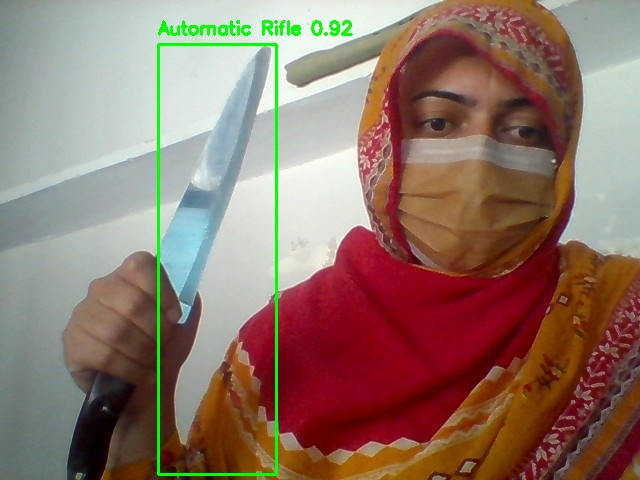

⚠️ GUN DETECTED! ALARM TRIGGERED!

🔄 Capture #2 - Button dabayein 👆


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [64]:
# ==========================================
# LIVE CAMERA DETECTION (Improved)
# - Sirf 9 classes (weapons) detect karega
# - Har capture ke baad camera off
# ==========================================

from ultralytics import YOLO
import cv2
import numpy as np
import base64
import time
from IPython.display import display, Javascript, Image, clear_output
from google.colab.output import eval_js

# ---- Load Model ----
if 'model' not in dir():
    model = YOLO('/content/runs/detect/train-5/weights/best.pt')
    print("✅ Model loaded!")

# ---- Sirf yeh 9 classes detect hongi (baki sab ignore) ----
class_names = ['Automatic Rifle', 'Bazooka', 'Grenade Launcher', 'Handgun', 'Knife', 'Shotgun', 'SMG', 'Sniper', 'Sword']
VALID_CLASS_IDS = list(range(9))  # 0 se 8 tak (sirf hamari classes)
GUN_CLASSES = [0, 1, 3, 5, 6, 7]  # Gun IDs
KNIFE_ID = 4  # Knife ID

# ---- Alarm Function ----
def play_beep():
    js_code = """
    if (window._osc) {
        try { window._osc.stop(); } catch(e) {}
        window._osc = null;
    }
    var audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    var oscillator = audioCtx.createOscillator();
    var gainNode = audioCtx.createGain();
    oscillator.connect(gainNode);
    gainNode.connect(audioCtx.destination);
    oscillator.frequency.value = 800;
    oscillator.type = 'square';
    gainNode.gain.value = 0.3;
    oscillator.start();
    window._osc = oscillator;
    setTimeout(function() {
        if (window._osc) {
            try { window._osc.stop(); } catch(e) {}
            window._osc = null;
        }
    }, 300);
    """
    display(Javascript(js_code))

def play_alarm():
    play_beep()
    print("\033[91m" + "🚨🚨 GUN DETECTED! ALARM! 🚨🚨" + "\033[0m")

# ---- Capture function (Camera off after capture) ----
def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture';
            capture.style.fontSize = '20px';
            capture.style.padding = '10px 30px';
            capture.style.margin = '10px';
            capture.style.cursor = 'pointer';
            div.appendChild(capture);
            document.body.appendChild(div);

            const status = document.createElement('p');
            status.textContent = '⏳ Camera starting...';
            status.style.fontSize = '16px';
            div.appendChild(status);

            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.width = '400px';
            video.style.margin = '10px 0';

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();

            status.textContent = '📸 Click "Capture" to take photo';

            await new Promise((resolve) => capture.onclick = resolve);

            status.textContent = '⏳ Processing...';

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            // 🔥 Camera OFF - Stream band karein
            stream.getTracks().forEach(track => track.stop());
            video.remove();
            status.textContent = '✅ Camera off';

            // Wait a moment then remove button
            setTimeout(() => {
                div.remove();
            }, 500);

            return canvas.toDataURL('image/jpeg', 0.9);
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = base64.b64decode(data.split(',')[1])
    np_arr = np.frombuffer(binary, np.uint8)
    return cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# ================================================
# 🎬 MAIN LOOP - 5 Captures
# ================================================

print("📸 Live Detection - Sirf Weapons detect honge!")
print("⚠️ Insan, animals, ya kisi aur cheez ko ignore karega.")
print("\n🔴 5 captures honge. Har baar 'Capture' button dabayein.")
print("-" * 50)

for i in range(5):
    print(f"\n🔄 Capture #{i+1} - Button dabayein 👆")

    # Capture photo (camera automatically off ho jayega)
    frame = take_photo()

    # Detection
    results = model(frame)

    # 🔥 FILTER: Sirf hamari 9 classes ko show karein
    # Pehle annotated frame banayein (sirf valid classes ke saath)
    annotated_frame = frame.copy()
    gun_detected = False
    knife_detected = False

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])

            # Sirf valid classes (0-8) ko process karein
            if cls_id in VALID_CLASS_IDS:
                name = class_names[cls_id]

                # Bounding box draw karein (manual)
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                label = f"{name} {conf:.2f}"
                cv2.putText(annotated_frame, label, (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

                # Gun check
                if cls_id in GUN_CLASSES:
                    gun_detected = True
                    play_alarm()
                    print(f"🔫 Detected: {name} (Confidence: {conf:.2f})")
                elif cls_id == KNIFE_ID:
                    knife_detected = True
                    print(f"🔪 Detected: {name} (Confidence: {conf:.2f})")
                else:
                    print(f"🔍 Detected: {name} (Confidence: {conf:.2f})")

    # Agar kuch detect nahi hua toh message
    if not gun_detected and not knife_detected:
        # Check ke koi valid detection thi ya nahi
        any_detected = False
        for r in results:
            for box in r.boxes:
                if int(box.cls[0]) in VALID_CLASS_IDS:
                    any_detected = True
                    break
            if any_detected:
                break
        if not any_detected:
            print("✅ No weapon detected")

    # Display result
    _, jpeg = cv2.imencode('.jpg', annotated_frame)
    display(Image(data=jpeg.tobytes()))

    # Final status
    if gun_detected:
        print("\033[91m" + "⚠️ GUN DETECTED! ALARM TRIGGERED!" + "\033[0m")
    elif knife_detected:
        print("🔪 Knife detected (No alarm)")
    else:
        print("✅ Safe - No gun or knife detected")

    time.sleep(0.5)

print("\n" + "="*50)
print("✅ Live detection complete! Camera off ho gayi.")

In [68]:
from google.colab import files
files.download('/content/runs/detect/train-5/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>